In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

Mounted at /content/drive


In [2]:
base_path = "/content/drive/MyDrive/CVPR/HAM10000"
metadata_path = os.path.join(base_path, "HAM10000_metadata.csv")
img_path_1 = os.path.join(base_path, "HAM10000_images_part_1")
img_path_2 = os.path.join(base_path, "HAM10000_images_part_2")

df = pd.read_csv(metadata_path)
print(df.shape)
print(df.head())
print(df["dx"].value_counts())

(10015, 7)
     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [3]:
print(os.path.exists(base_path))
print(os.path.exists(img_path_1))
print(os.path.exists(img_path_2))
print(os.path.exists(metadata_path))

True
True
True
True


In [4]:
# Step 2: Label Encoding

# Create label mapping
label_mapping = {label: idx for idx, label in enumerate(df["dx"].unique())}
df["label"] = df["dx"].map(label_mapping)

print("Label Mapping:")
print(label_mapping)

Label Mapping:
{'bkl': 0, 'nv': 1, 'df': 2, 'mel': 3, 'vasc': 4, 'bcc': 5, 'akiec': 6}


In [5]:
# Step 3: Image Path Mapping

def get_image_path(image_id):
    path1 = os.path.join(img_path_1, image_id + ".jpg")
    path2 = os.path.join(img_path_2, image_id + ".jpg")

    if os.path.exists(path1):
        return path1
    elif os.path.exists(path2):
        return path2
    else:
        return None

df["image_path"] = df["image_id"].apply(get_image_path)

# Drop missing paths (safety check)
df = df[df["image_path"].notnull()]

print("Total usable images:", len(df))
df.head()

Total usable images: 10015


,lesion_id,image_id,dx,dx_type,age,sex,localization,label,image_path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,0,/content/drive/MyDrive/CVPR/HAM10000/HAM10000_...
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,0,/content/drive/MyDrive/CVPR/HAM10000/HAM10000_...
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,0,/content/drive/MyDrive/CVPR/HAM10000/HAM10000_...
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,0,/content/drive/MyDrive/CVPR/HAM10000/HAM10000_...
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,0,/content/drive/MyDrive/CVPR/HAM10000/HAM10000_...


(np.float64(-0.5), np.float64(599.5), np.float64(449.5), np.float64(-0.5))

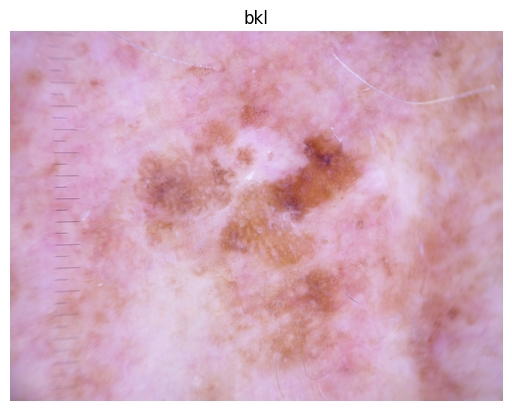

In [6]:
# Check one image manually

sample = df.iloc[0]
img = Image.open(sample["image_path"])

plt.imshow(img)
plt.title(sample["dx"])
plt.axis("off")

In [7]:
from sklearn.model_selection import train_test_split

# First split: Train + Temp (80% train, 20% temp)
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

# Second split: Validation + Test (10% each)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=42
)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

Train size: 8012
Validation size: 1001
Test size: 1002


In [8]:
# Step: Data Transforms

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [9]:
class HAMDataset(Dataset):
    def __init__(self, dataframe, transform=None):

         # Reset index to ensure proper indexing
        self.df = dataframe.reset_index(drop=True)
         # Store transformations
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        # Retrieve image path and corresponding label using index
        img_path = self.df.loc[idx, "image_path"]
        label = self.df.loc[idx, "label"]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [10]:
train_dataset = HAMDataset(train_df, transform=train_transforms)
val_dataset = HAMDataset(val_df, transform=val_test_transforms)
test_dataset = HAMDataset(test_df, transform=val_test_transforms)

print(len(train_dataset), len(val_dataset), len(test_dataset))

8012 1001 1002


In [18]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)
print("DataLoaders ready!")

DataLoaders ready!


In [12]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes=7):
        super(CustomCNN, self).__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CustomCNN(num_classes=7).to(device)

print(model)

CustomCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=256, bias=True)
    (2): ReLU()
    (3): Drop

In [14]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

In [19]:
# Model Training Loop
num_epochs = 3
best_val_acc = 0

# Lists to store loss and accuracy for visualization
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Loop over each epoch
for epoch in range(num_epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0


 # Training Phase
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # Validation
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_acc = correct / total

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    if val_acc > best_val_acc:
      best_val_acc = val_acc
      torch.save(model.state_dict(), "/content/drive/MyDrive/CVPR/best_model.pth")


    scheduler.step()

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    print("-" * 40)

Epoch [1/3]
Train Loss: 1.0945, Train Acc: 0.6643
Val Loss: 0.9032, Val Acc: 0.6693
----------------------------------------
Epoch [2/3]
Train Loss: 1.0491, Train Acc: 0.6676
Val Loss: 0.8771, Val Acc: 0.6693
----------------------------------------
Epoch [3/3]
Train Loss: 1.0316, Train Acc: 0.6645
Val Loss: 1.0423, Val Acc: 0.6683
----------------------------------------


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score

In [21]:
# Load best saved model
model = CustomCNN(num_classes=7).to(device)
model.load_state_dict(torch.load("/content/drive/MyDrive/CVPR/best_model.pth", map_location=device))
model.eval()
print("Best model loaded successfully.")

Best model loaded successfully.


In [22]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [23]:
class_names = list(label_mapping.keys())

print("Precision:", precision_score(all_labels, all_preds, average="weighted"))
print("Recall:", recall_score(all_labels, all_preds, average="weighted"))
print("F1-score:", f1_score(all_labels, all_preds, average="weighted"))
print()
print(classification_report(all_labels, all_preds, target_names=class_names))

Precision: 0.44844542452022107
Recall: 0.6696606786427146
F1-score: 0.5371695342131039

              precision    recall  f1-score   support

         bkl       0.00      0.00      0.00       110
          nv       0.67      1.00      0.80       671
          df       0.00      0.00      0.00        11
         mel       0.00      0.00      0.00       112
        vasc       0.00      0.00      0.00        14
         bcc       0.00      0.00      0.00        52
       akiec       0.00      0.00      0.00        32

    accuracy                           0.67      1002
   macro avg       0.10      0.14      0.11      1002
weighted avg       0.45      0.67      0.54      1002



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

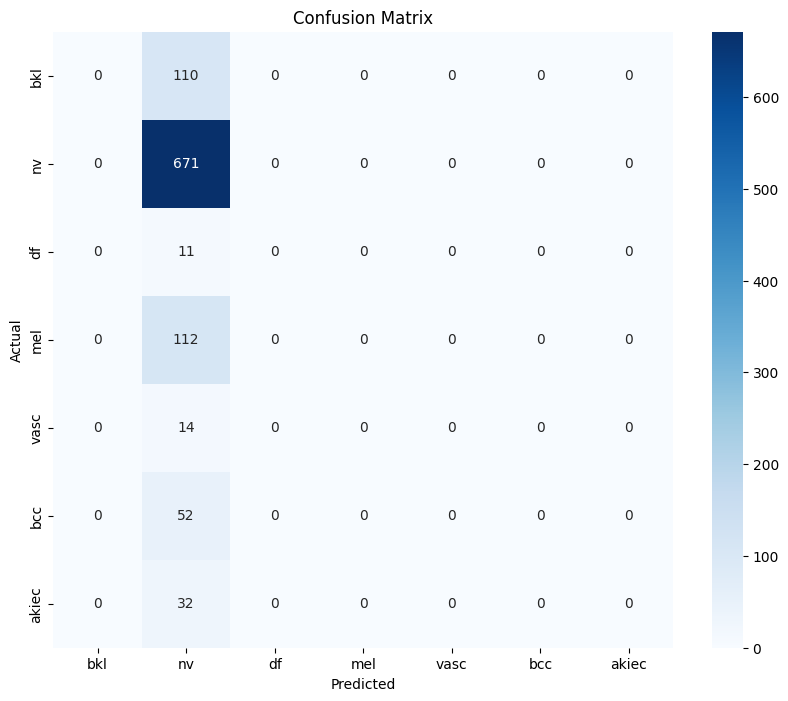

In [24]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

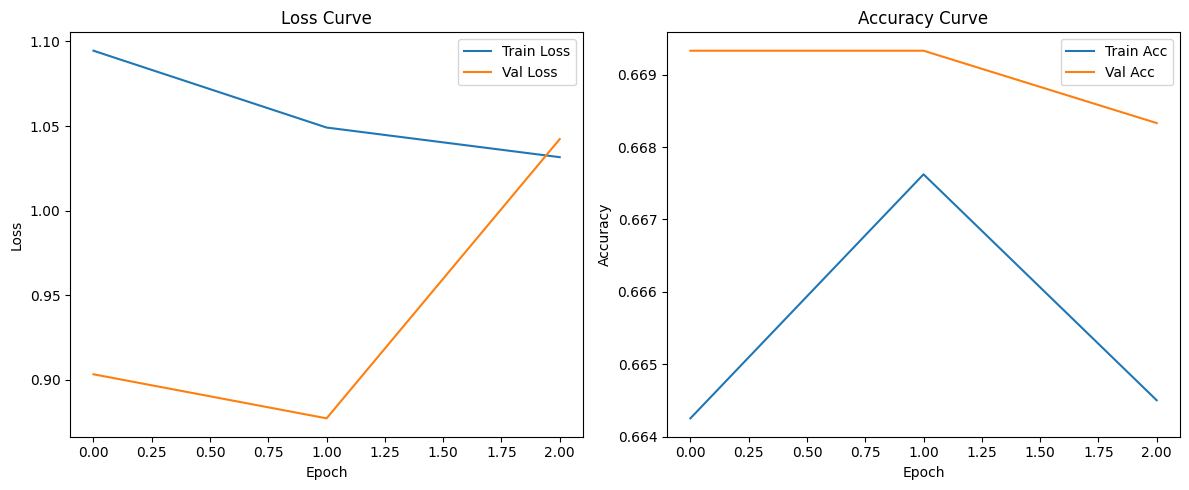

In [25]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Acc")
plt.plot(val_accuracies, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()

plt.tight_layout()
plt.show()

In [26]:
per_class_correct = cm.diagonal()
per_class_total = cm.sum(axis=1)
per_class_acc = per_class_correct / per_class_total

for i, cls in enumerate(class_names):
    print(cls, ":", round(per_class_acc[i], 4))

best_idx = per_class_acc.argmax()
worst_idx = per_class_acc.argmin()

print("\nBest class:", class_names[best_idx], round(per_class_acc[best_idx], 4))
print("Worst class:", class_names[worst_idx], round(per_class_acc[worst_idx], 4))

bkl : 0.0
nv : 1.0
df : 0.0
mel : 0.0
vasc : 0.0
bcc : 0.0
akiec : 0.0

Best class: nv 1.0
Worst class: bkl 0.0


## Experiment: CNN without Batch Normalization and Dropout


In [28]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=7):
        super(BaselineCNN, self).__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [29]:
model = BaselineCNN().to(device)

In [33]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [34]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

In [35]:
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

In [36]:
num_epochs = 3
best_val_acc = 0

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0



    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # Validation
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_acc = correct / total

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    if val_acc > best_val_acc:
      best_val_acc = val_acc
      torch.save(model.state_dict(), "/content/drive/MyDrive/CVPR/best_model.pth")


    scheduler.step()

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    print("-" * 40)

Epoch [1/3]
Train Loss: 0.9580, Train Acc: 0.6721
Val Loss: 0.9130, Val Acc: 0.6753
----------------------------------------
Epoch [2/3]
Train Loss: 0.8955, Train Acc: 0.6737
Val Loss: 0.9359, Val Acc: 0.6743
----------------------------------------
Epoch [3/3]
Train Loss: 0.8517, Train Acc: 0.6918
Val Loss: 0.7904, Val Acc: 0.7153
----------------------------------------


In [37]:
# Importing libraries for visualization and performance evaluation
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score

In [39]:
# Model Preparation for Testing
model = BaselineCNN(num_classes=7).to(device)
model.eval()
print("Baseline model ready.")

Baseline model ready.


In [40]:
all_preds = []
all_labels = []

# Disable gradient computation for faster inference
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [41]:
# Classification Metrics
class_names = list(label_mapping.keys())

print("Precision:", precision_score(all_labels, all_preds, average="weighted"))
print("Recall:", recall_score(all_labels, all_preds, average="weighted"))
print("F1-score:", f1_score(all_labels, all_preds, average="weighted"))
print()
print(classification_report(all_labels, all_preds, target_names=class_names))

Precision: 0.0026932163616878017
Recall: 0.05189620758483034
F1-score: 0.005120688414442462

              precision    recall  f1-score   support

         bkl       0.00      0.00      0.00       110
          nv       0.00      0.00      0.00       671
          df       0.00      0.00      0.00        11
         mel       0.00      0.00      0.00       112
        vasc       0.00      0.00      0.00        14
         bcc       0.05      1.00      0.10        52
       akiec       0.00      0.00      0.00        32

    accuracy                           0.05      1002
   macro avg       0.01      0.14      0.01      1002
weighted avg       0.00      0.05      0.01      1002



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

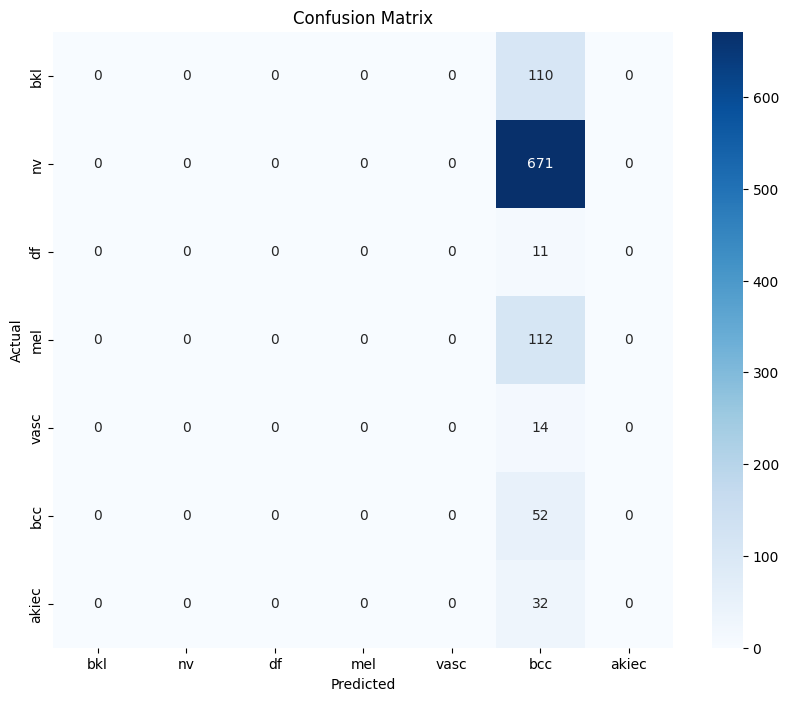

In [42]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

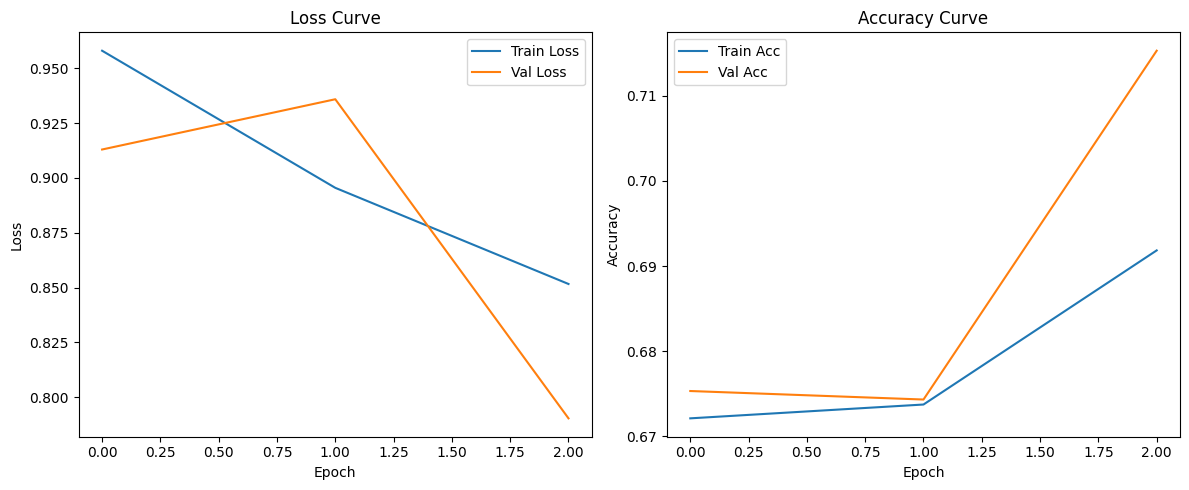

In [43]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Acc")
plt.plot(val_accuracies, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()

plt.tight_layout()
plt.show()

In [44]:
per_class_correct = cm.diagonal()
per_class_total = cm.sum(axis=1)
per_class_acc = per_class_correct / per_class_total

for i, cls in enumerate(class_names):
    print(cls, ":", round(per_class_acc[i], 4))

best_idx = per_class_acc.argmax()
worst_idx = per_class_acc.argmin()

print("\nBest class:", class_names[best_idx], round(per_class_acc[best_idx], 4))
print("Worst class:", class_names[worst_idx], round(per_class_acc[worst_idx], 4))

bkl : 0.0
nv : 0.0
df : 0.0
mel : 0.0
vasc : 0.0
bcc : 1.0
akiec : 0.0

Best class: bcc 1.0
Worst class: bkl 0.0


In [45]:
torch.save(model.state_dict(), "/content/drive/MyDrive/CVPR/baseline_model.pth")

In [46]:
import os
print(os.path.exists("/content/drive/MyDrive/CVPR/best_model.pth"))

True


In [47]:
torch.save(model.state_dict(), "/content/drive/MyDrive/CVPR/baseline_model.pth")

## **Analysis & Discussion of Results**

This study investigated the performance of a custom Convolutional Neural Network (CNN) on the HAM10000 skin lesion dataset, a multi-class medical image classification problem consisting of seven diagnostic categories. A key characteristic of this dataset is its significant class imbalance, with the `nv` class dominating the distribution. This imbalance played a critical role in shaping the behavior and performance of the trained models.

Two model configurations were evaluated: a CNN with Batch Normalization and Dropout (regularized model), and a baseline CNN without these components. The regularized model demonstrated relatively stable training behavior, as reflected in the gradual decrease in training loss and moderate improvement in validation accuracy. However, detailed evaluation revealed that the model exhibited a strong bias toward the majority class. The confusion matrix clearly indicates that a large proportion of samples were classified into a single dominant category, resulting in poor recall for minority classes such as `bkl`, `df`, `mel`, `vasc`, `bcc`, and `akiec`.

The classification report further supports this observation. While weighted metrics (precision, recall, and F1-score) appear moderately acceptable, macro-averaged metrics are significantly lower, indicating that performance across classes is highly uneven. This discrepancy confirms that the model performs well primarily on the majority class while failing to generalize effectively across underrepresented categories.

The baseline model without Batch Normalization and Dropout showed even poorer generalization on the test set. The confusion matrix suggests near-complete prediction collapse into a single class, and the resulting evaluation metrics are substantially lower than those of the regularized model. This comparison highlights that Batch Normalization and Dropout contribute positively to training stability and generalization, although their impact is limited in the presence of severe class imbalance.

Overall, the results demonstrate that while the implemented CNN architecture is functional and capable of learning basic feature representations, its effectiveness is significantly constrained by the dataset’s imbalance. The observed bias toward dominant classes underscores the importance of incorporating data-level or loss-level balancing strategies when working with imbalanced medical datasets.

# **Conclusions & Future Work**

The best model was selected based on highest validation accuracy and saved as best_model.pth.

This project successfully developed and evaluated a complete deep learning pipeline for multi-class image classification using the HAM10000 dataset. The implementation includes data preprocessing, dataset splitting, custom CNN architecture design, training with appropriate optimization techniques, and comprehensive model evaluation using quantitative metrics and visualizations. All core requirements of the assignment have been addressed in a structured and reproducible manner.

The experimental results indicate that the custom CNN is capable of learning meaningful representations from the dataset; however, its overall performance is limited by the highly imbalanced class distribution. The model consistently favors the majority class, leading to significantly lower performance on minority classes. While the inclusion of Batch Normalization and Dropout improved training stability and yielded better results compared to the baseline model, these techniques alone were insufficient to achieve balanced classification performance.

To improve the model’s effectiveness, future work should focus on addressing the class imbalance problem more directly. Potential strategies include the use of class-weighted loss functions, oversampling of minority classes, application of advanced data augmentation techniques, or implementation of a weighted sampling mechanism within the DataLoader. Additionally, increasing the number of training epochs and performing systematic hyperparameter tuning may lead to incremental improvements in performance.

Further enhancements could involve experimenting with deeper architectures or leveraging transfer learning from pretrained models, which have been shown to perform well on medical image classification tasks. Techniques such as early stopping and regularization tuning could also help prevent overfitting and improve generalization.

In conclusion, this project provides a solid baseline implementation and highlights a critical insight in deep learning: model performance is strongly influenced not only by architecture design but also by dataset characteristics. Addressing data imbalance is essential for achieving robust and reliable classification in real-world medical applications.